In [1]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import keras
import keras_nlp
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import Pool
import joblib
import os
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import tensorflow as tf
import random

2026-04-14 23:13:31.930549: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# nltk.download('wordnet')
# nltk.download('stopwords')
# nltk.download('punkt')

In [3]:
# set pure Python random seed
random.seed(1)

# set NumPy random seed
np.random.seed(1)

# set TensorFlow/Keras random seed
tf.random.set_seed(1)

## Data Loading and Preprocessing

### Agricultural Data

In [4]:
# load json files
human_listings_ag = pd.read_json("scraping/agricultural/human_listings.json")
ai_listings_ag = pd.read_json("scraping/agricultural/ai_listings.json")

# add source_model column to human listings
human_listings_ag["source_model"] = "human"

# combine datasets
combined_listings_ag = pd.concat([human_listings_ag, ai_listings_ag], ignore_index=True)

# encode target variable
# Human = 0, AI = 1
combined_listings_ag["target"] = combined_listings_ag["label"].map({"Human": 0, "AI": 1})

# combine text features (name + description)
combined_listings_ag["full_text"] = combined_listings_ag["name"].fillna("") + " - " + combined_listings_ag["description"].fillna("")

# drop unused columns
combined_listings_ag_clean = combined_listings_ag.drop(columns=["id", "url", "name", "description", "label"])

combined_listings_ag_clean

,source_model,target,full_text
0,human,0,Soulful Seeds - Soulful Seeds is a social and ...
1,human,0,"Urban Earth Care Farm - Urban Earth Care Farm,..."
2,human,0,Navarro Farm - The Navarro family 5-acre farm ...
3,human,0,The Farm At Our House - We are committed to su...
4,human,0,Arcadia Farm - Arcadia is a nonprofit organiza...
...,...,...,...
785,openai/gpt-oss-120b,1,Horizon Grove - Nestled in the rolling hills o...
786,openai/gpt-oss-120b,1,Maple Creek Orchard - Located on the gentle ro...
787,openai/gpt-oss-120b,1,Cedar Ridge Farm - Nestled on a 30‑acre histor...
788,openai/gpt-oss-120b,1,Island Roots Project - Located in the heart of...


### Job Data

In [5]:
# load cleaned job data
job_data = pd.read_csv("scraping/jobs/combined_jobs.csv")

job_data

,target,source_model,full_text
0,0,human,Manager Data Analytics - The Manager Data Anal...
1,0,human,Machine Learning Architect (Senior Consultant)...
2,0,human,"DATABASE ARCHITECT - StrideCare, a healthcare ..."
3,0,human,"Senior Backend Engineer, AI - Who is Recruitin..."
4,0,human,Senior Data Scientist - Overview: LMI is seeki...
...,...,...,...
2995,1,perplexity,Applied Scientist - Job Summary: Brightline AI...
2996,1,perplexity,Analytics Manager - Job Summary: Parallel Orbi...
2997,1,perplexity,Senior Data Scientist - Job Summary: Crescent ...
2998,1,perplexity,Computer Vision Engineer - Role Summary: Summi...


### Social Media Data

In [6]:
# load social media data
social_media_data = pd.read_csv("scraping/social_media/Combined_Dataset.csv")

# rename title to full_text
social_media_data = social_media_data.rename(columns={"Title": "full_text"})

# fill any missing text values with an empty string to prevent cleaning errors
social_media_data["full_text"] = social_media_data["full_text"].fillna("")

# filter the DataFrame to only include the required columns
social_media_data_clean = social_media_data[["full_text", "target", "source_model"]]

social_media_data_clean

,full_text,target,source_model
0,Protests break out in major cities over new ta...,1,gemini
1,ABC pulls Taylor Frankie Paul's season of 'Bac...,0,human
2,Researchers uncover unusual pattern in Arctic ...,1,chatgpt
3,Heavy metal memorabilia on offer at Julien's '...,1,chatgpt
4,Rays RHP Ryan Pepiot (hip) to begin season on ...,1,chatgpt
...,...,...,...
1201,US federal jury convicts Assad-era Syrian offi...,0,human
1202,Air Canada flight hits vehicle on runway at La...,0,human
1203,Florida bill against marrying your first cousi...,0,human
1204,Exclusive: Iran wants 'serious review' of Gulf...,0,human


### Combined Datasets

In [7]:
# combine agricultural, job, and social media datasets
final_combined_listings = pd.concat(
    [combined_listings_ag_clean, job_data, social_media_data_clean], 
    ignore_index=True
)

# perform train-test split (80:20)
X_train_base, X_test_base, y_train, y_test = train_test_split(
    final_combined_listings["full_text"],
    final_combined_listings["target"],
    test_size=0.2,
    random_state=1,
    stratify=final_combined_listings["target"]
)

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def deep_clean_text(text):
    # convert to lowercase
    text = text.lower()

    # remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # rejoin into single string
    return " ".join(words)

## CatBoost

In [9]:
# apply the cleaning function to the train and test splits
X_train_clean = X_train_base.apply(deep_clean_text)
X_test_clean = X_test_base.apply(deep_clean_text)

# convert to DataFrame
X_train_df = pd.DataFrame({'full_text': X_train_clean})
X_test_df = pd.DataFrame({'full_text': X_test_clean})

In [10]:
# initalize CatBoost Classifier
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    loss_function='Logloss', # binary classification
    eval_metric='Accuracy',
    verbose=100,
    allow_writing_files=False
)

# train model
# pass the column name as a list to the text_features parameter
catboost_model.fit(
    X_train_df, 
    y_train, 
    text_features=['full_text'], 
    eval_set=(X_test_df, y_test)
)

0:	learn: 0.9156657	test: 0.9270000	best: 0.9270000 (0)	total: 118ms	remaining: 1m 57s
100:	learn: 0.9594595	test: 0.9410000	best: 0.9420000 (95)	total: 5.77s	remaining: 51.4s
200:	learn: 0.9759760	test: 0.9410000	best: 0.9430000 (178)	total: 11.2s	remaining: 44.4s
300:	learn: 0.9874875	test: 0.9380000	best: 0.9430000 (178)	total: 16.5s	remaining: 38.4s
400:	learn: 0.9912412	test: 0.9400000	best: 0.9430000 (178)	total: 21.9s	remaining: 32.7s
500:	learn: 0.9937437	test: 0.9420000	best: 0.9430000 (178)	total: 27.3s	remaining: 27.2s
600:	learn: 0.9962462	test: 0.9400000	best: 0.9430000 (178)	total: 32.6s	remaining: 21.6s
700:	learn: 0.9974975	test: 0.9400000	best: 0.9430000 (178)	total: 38.2s	remaining: 16.3s
800:	learn: 0.9979980	test: 0.9390000	best: 0.9430000 (178)	total: 43.9s	remaining: 10.9s
900:	learn: 0.9982482	test: 0.9420000	best: 0.9430000 (178)	total: 49.6s	remaining: 5.45s
999:	learn: 0.9987487	test: 0.9420000	best: 0.9430000 (178)	total: 55.7s	remaining: 0us

bestTest = 0.94

CatBoostClassifier(allow_writing_files=False, eval_metric='Accuracy', iterations=1000, learning_rate=0.1, loss_function='Logloss', verbose=100)

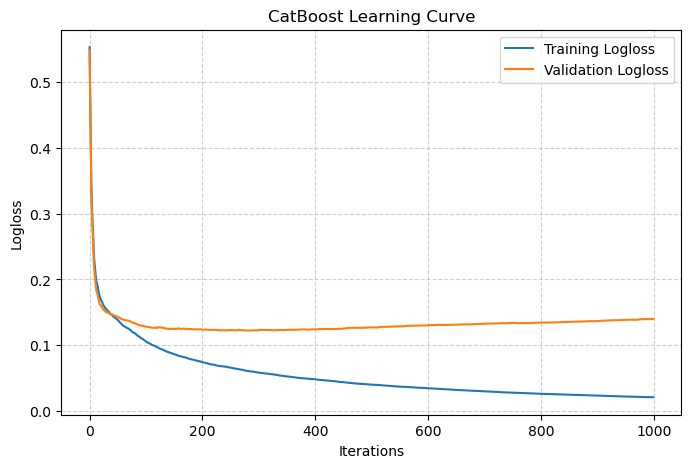

In [11]:
# CatBoost Learning Curve
evals_result = catboost_model.get_evals_result()

plt.figure(figsize=(8, 5))
plt.plot(evals_result['learn']['Logloss'], label='Training Logloss')
plt.plot(evals_result['validation']['Logloss'], label='Validation Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

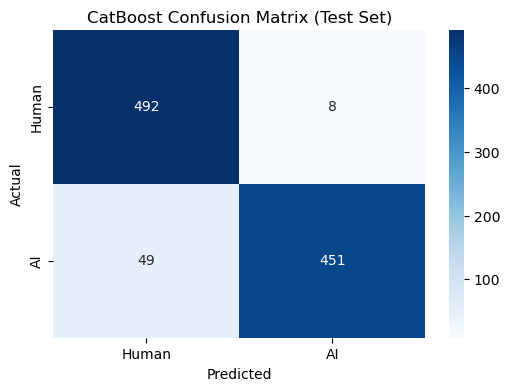


--- CatBoost Results ---
Accuracy: 0.9430

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.91      0.98      0.95       500
      AI (1)       0.98      0.90      0.94       500

    accuracy                           0.94      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.95      0.94      0.94      1000



In [12]:
# predictions and evaluation
catboost_pred = catboost_model.predict(X_test_df)

# confusion matrix
cm = confusion_matrix(y_test, catboost_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human", "AI"], 
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- CatBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, catboost_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, catboost_pred, target_names=['Human (0)', 'AI (1)']))

## TF-IDF {Logistic Regression, Random Forest, SVM, XGBoost}

In [13]:
# apply deep cleaning
X_train_cleaned = X_train_base.apply(deep_clean_text)
X_test_cleaned = X_test_base.apply(deep_clean_text)

# train TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit only on training data, then transform both
X_train_tfidf = tfidf.fit_transform(X_train_cleaned)
X_test_tfidf = tfidf.transform(X_test_cleaned)

### Logistic Regression

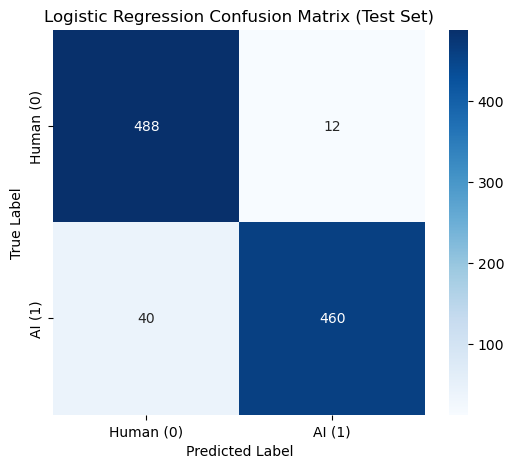


--- Logistic Regression Results ---
Accuracy: 0.9480

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.92      0.98      0.95       500
      AI (1)       0.97      0.92      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [14]:
# Logistic Regression on TF-IDF features
lr_model = LogisticRegression(max_iter=1000, random_state=1)
lr_model.fit(X_train_tfidf, y_train)

# predict on test set
lr_preds = lr_model.predict(X_test_tfidf)

# confusion matrix
lr_cm = confusion_matrix(y_test, lr_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human (0)", "AI (1)"],
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix (Test Set)")
plt.show()

# classification report
print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Human (0)', 'AI (1)']))

### Random Forest

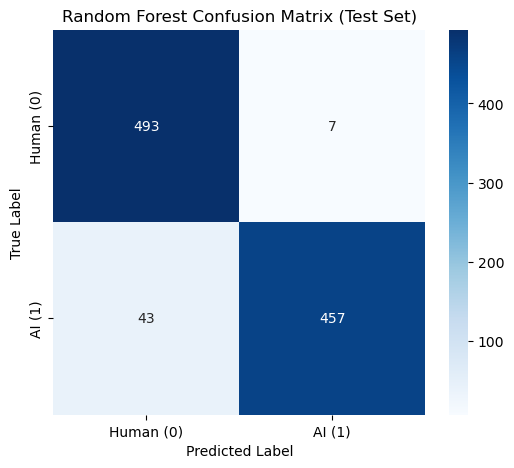


--- Random Forest Results ---
Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.92      0.99      0.95       500
      AI (1)       0.98      0.91      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [15]:
# Random Forest on TF-IDF features
rf_model = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# predict on test set
rf_preds = rf_model.predict(X_test_tfidf)

# confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human (0)", "AI (1)"],
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix (Test Set)")
plt.show()

# classification report
print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Human (0)', 'AI (1)']))

### SVM

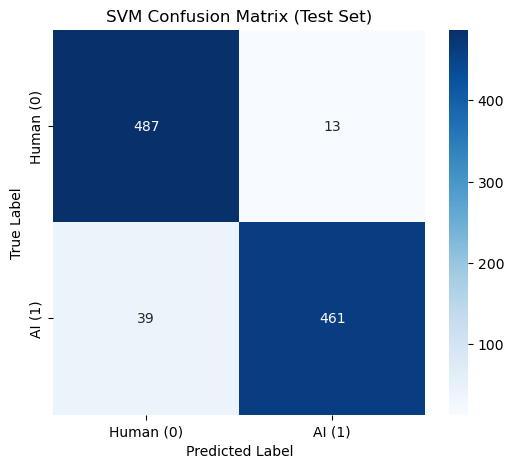


--- SVM Results ---
Accuracy: 0.9480

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.93      0.97      0.95       500
      AI (1)       0.97      0.92      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [16]:
# initialize the SVM with linear kernel
svm_model = SVC(kernel='linear', random_state=1)

# train the model using the TF-IDF vectorized training data
svm_model.fit(X_train_tfidf, y_train)

# predict on the test set
svm_preds = svm_model.predict(X_test_tfidf)

# display confusion matrix
conf_matrix = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=['Human (0)', 'AI (1)']))

### XGBoost

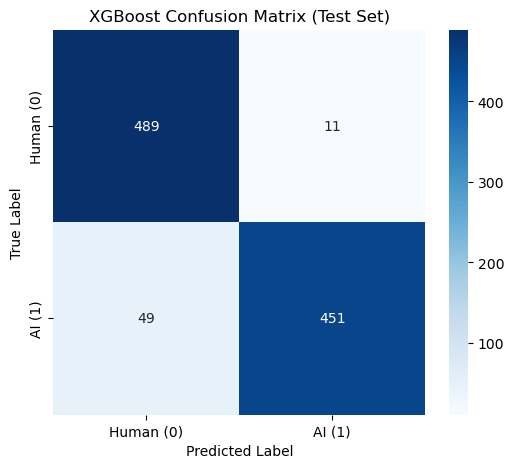


--- XGBoost Results ---
Accuracy: 0.9400

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.91      0.98      0.94       500
      AI (1)       0.98      0.90      0.94       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



In [17]:
# initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300, 
    max_depth=3, 
    learning_rate=0.1,
    eval_metric='logloss', 
    random_state=881
)

# train the model using the TF-IDF vectorized training data
xgb_model.fit(X_train_tfidf, y_train)

# predict on the test set
xgb_preds = xgb_model.predict(X_test_tfidf)

# confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human (0)", "AI (1)"],
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate XGBoost results
print("\n--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Human (0)', 'AI (1)']))

In [18]:
# Save TF-IDF vectorizer (shared by SVM, LR, RF, and XGBoost)
joblib.dump(tfidf, 'models/tfidf_jobs.pkl')

# Save scikit-learn models using joblib
joblib.dump(svm_model, 'models/svm_jobs.pkl')
joblib.dump(lr_model, 'models/lr_jobs.pkl')
joblib.dump(rf_model, 'models/rf_jobs.pkl')

# Save CatBoost and XGBoost using their native save methods
catboost_model.save_model('models/catboost_jobs.cbm')
xgb_model.save_model('models/xgboost_jobs.json')

## Fine-Tuned TinyBERT

In [19]:
def light_clean_text(text):
    # remove HTML tags if present
    text = re.sub(r'<.*?>', '', text)

    # remove extra whitespaces/lines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
# apply light cleaning
X_train_transformer = X_train_base.apply(light_clean_text).tolist()
X_test_transformer = X_test_base.apply(light_clean_text).tolist()

# create validation set (from the training data)
X_train_transformer, X_val_transformer, y_train_np, y_val_np = train_test_split(
    X_train_transformer, 
    y_train, 
    test_size=0.20,
    random_state=1, 
    stratify=y_train
)

# convert final test labels to numpy array for consistency
y_test_np = np.array(y_test)

In [21]:
# define the pre-trained model
preset = "bert_tiny_en_uncased"

# create preprocessor
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    preset=preset,
    sequence_length=128
)

# create classifier
classifier = keras_nlp.models.BertClassifier.from_preset(
    preset=preset,
    preprocessor=preprocessor,
    num_classes=2
)

# compile classifier
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    metrics=["accuracy"]
)

# display classifier summary
classifier.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 128), (None,      │       4,385,920 │ padding_mask[0][0],        │
│                               │ None, 128)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 128)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │             258 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,386,178 (16.73 MB)

 Trainable params: 4,386,178 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# define callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=3, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# fine-tune the BERT model 
history = classifier.fit(
    x=X_train_transformer,
    y=y_train_np,
    validation_data=(X_val_transformer, y_val_np),
    epochs=10,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 54s 231ms/step - accuracy: 0.6750 - loss: 0.6158 - val_accuracy: 0.8838 - val_loss: 0.3064 - learning_rate: 5.0000e-05
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 232ms/step - accuracy: 0.9313 - loss: 0.2241 - val_accuracy: 0.9450 - val_loss: 0.1368 - learning_rate: 5.0000e-05
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.9541 - loss: 0.1249 - val_accuracy: 0.9563 - val_loss: 0.1133 - learning_rate: 5.0000e-05
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.9735 - loss: 0.0792 - val_accuracy: 0.9588 - val_loss: 0.1098 - learning_rate: 5.0000e-05
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 221ms/step - accuracy: 0.9824 - loss: 0.0578 - val_accuracy: 0.9600 - val_loss: 0.1089 - learning_rate: 5.0000e-05
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.9855 - loss: 0.0542 - val_accuracy: 0.9588 - val_loss: 0.1067 - learning_rate: 5.0000e-05
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 22

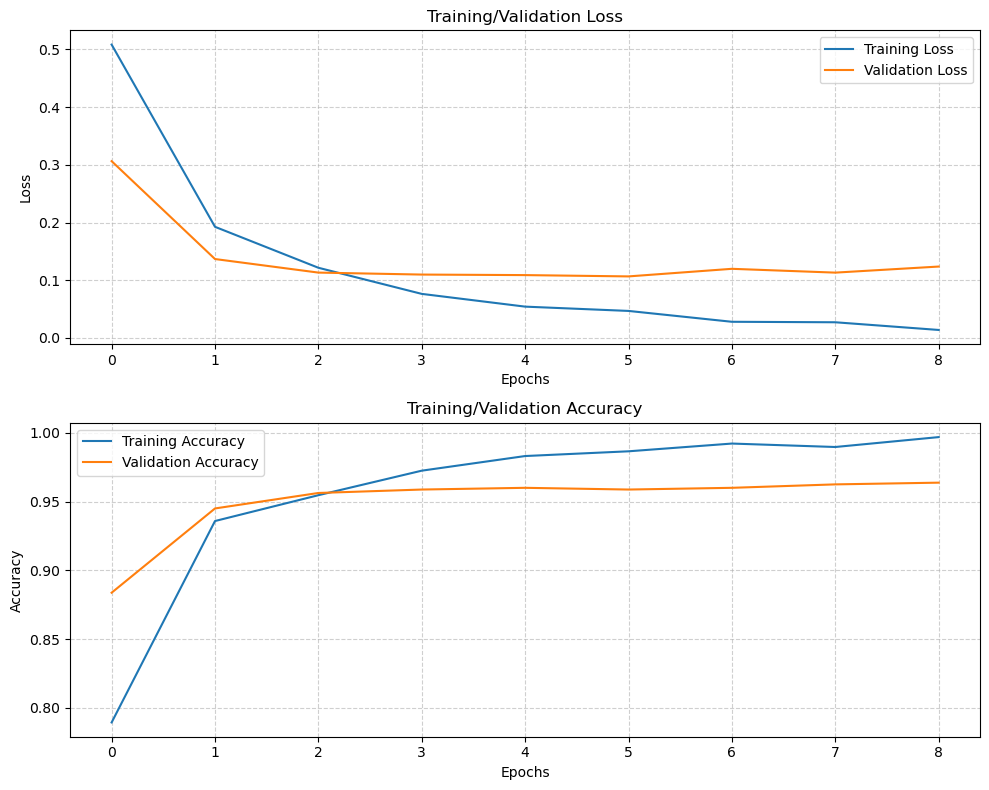

In [23]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], linestyle='-', label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], linestyle='-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.9580 - loss: 0.1516 
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step 


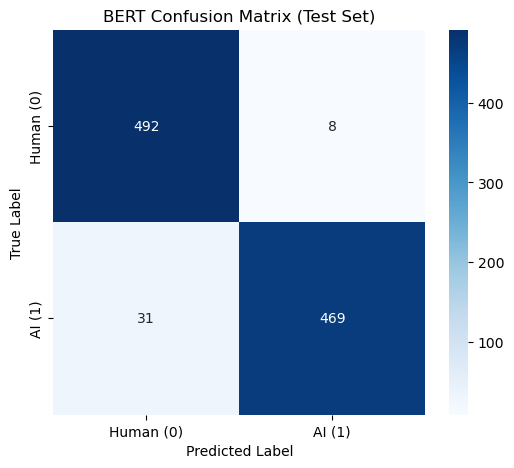


--- BERT Results ---
BERT Test Loss: 0.1444
BERT Test Accuracy: 0.9610

Classification Report:
              precision    recall  f1-score   support

   Human (0)       0.94      0.98      0.96       500
      AI (1)       0.98      0.94      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [24]:
# evaluate the fine-tuned BERT model
bert_test_loss, bert_test_accuracy = classifier.evaluate(
    x=X_test_transformer, 
    y=y_test_np, 
    verbose=1
)

# get predictions (these will be logits because from_logits=True)
test_preds = classifier.predict(X_test_transformer)

# convert logits to binary labels using argmax
pred_labels = np.argmax(test_preds, axis=1)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, pred_labels)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix (Test Set)")
plt.show()

# Print results
print("\n--- BERT Results ---")
print(f"BERT Test Loss: {bert_test_loss:.4f}")
print(f"BERT Test Accuracy: {bert_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_np, pred_labels, target_names=["Human (0)", "AI (1)"]))

In [25]:
# Save the fine-tuned TinyBERT model
classifier.save('models/tinybert_jobs.keras')

## Evaluation Visualizations

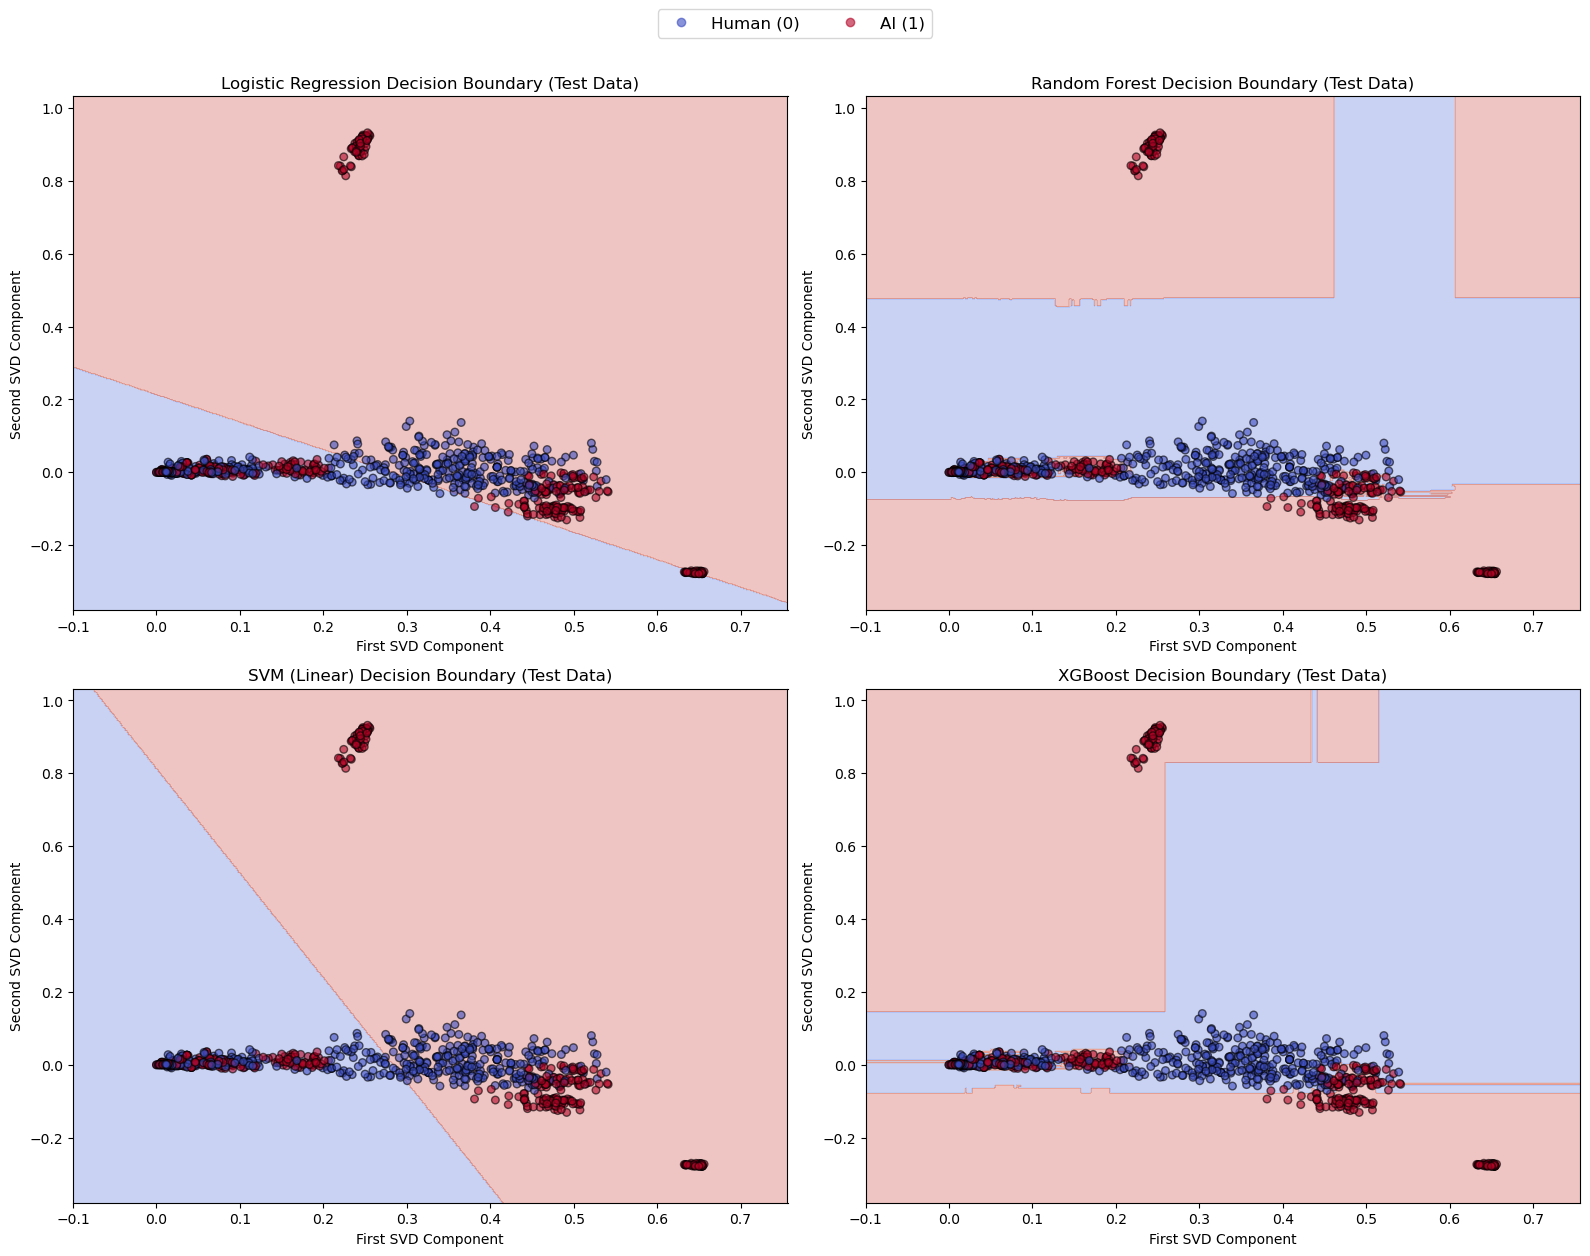

In [26]:
# Dimensionality Reduction (Using TruncatedSVD to save memory on sparse matrices)
svd = TruncatedSVD(n_components=2, random_state=42)

# Fit on training data, transform both train and test
X_train_2d = svd.fit_transform(X_train_tfidf)
X_test_2d = svd.transform(X_test_tfidf)

# Initialize the 2D versions of models
models_2d = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1),
    "SVM (Linear)": SVC(kernel='linear', random_state=1),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, 
                                 tree_method='hist', eval_metric='logloss', random_state=881)
}

# Train all 2D models
for name, model in models_2d.items():
    model.fit(X_train_2d, y_train)

# Set up the plotting grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel() # Flatten to 1D array for easy iteration

# Create the mesh grid for the background based on test set bounds
x_min, x_max = X_test_2d[:, 0].min() - 0.1, X_test_2d[:, 0].max() + 0.1
y_min, y_max = X_test_2d[:, 1].min() - 0.1, X_test_2d[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Loop through models to plot
for idx, (name, model) in enumerate(models_2d.items()):
    ax = axes[idx]
    
    # Predict across the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Draw the boundary contours
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    
    # Scatter the actual test data
    scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                         cmap="coolwarm", edgecolors='k', alpha=0.6, s=30)
    
    ax.set_title(f'{name} Decision Boundary (Test Data)')
    ax.set_xlabel('First SVD Component')
    ax.set_ylabel('Second SVD Component')

# Add a shared legend to the figure
legend_elements = scatter.legend_elements()[0]
fig.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"], 
           loc="upper center", ncol=2, fontsize=12, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

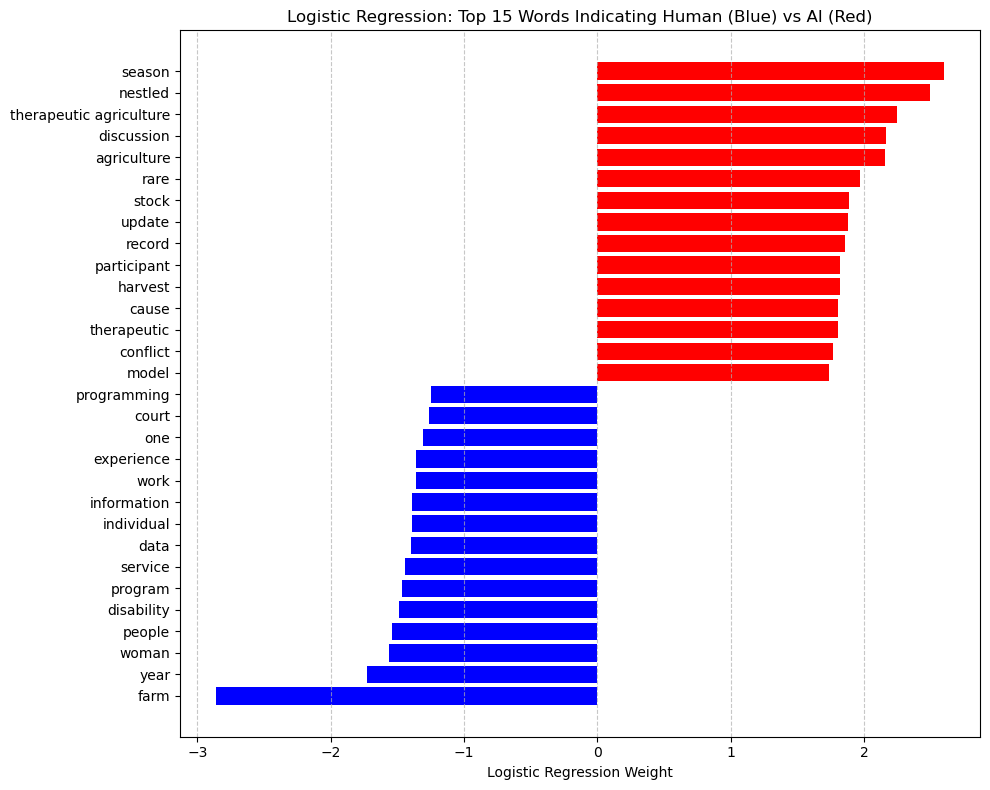

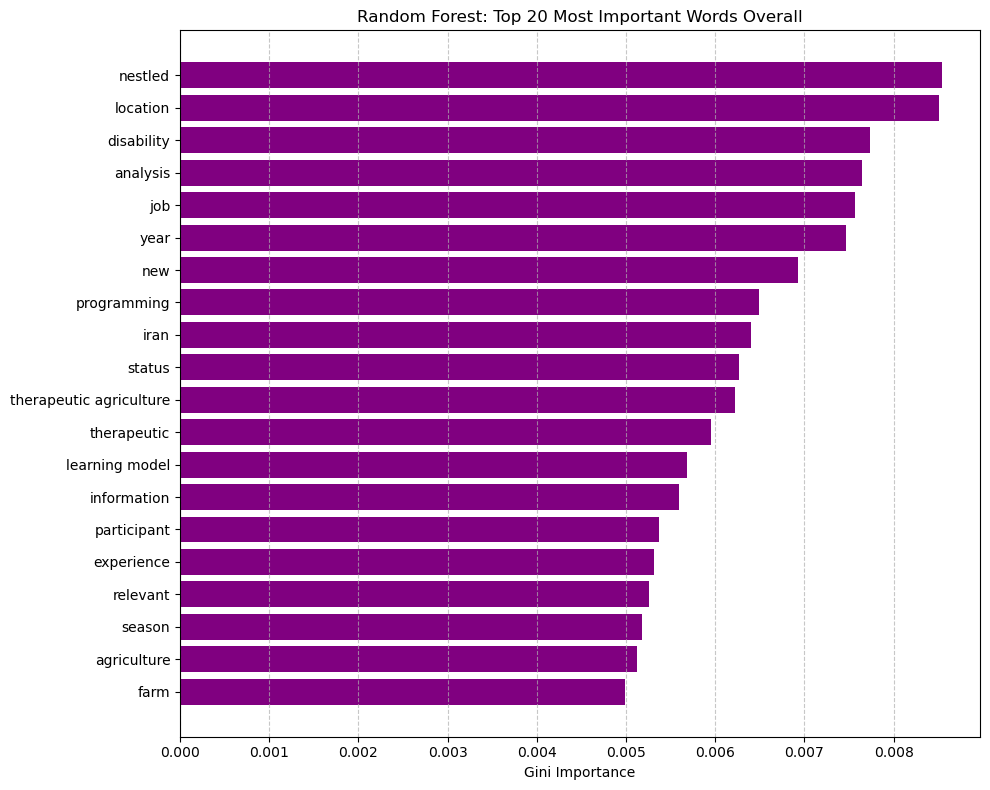

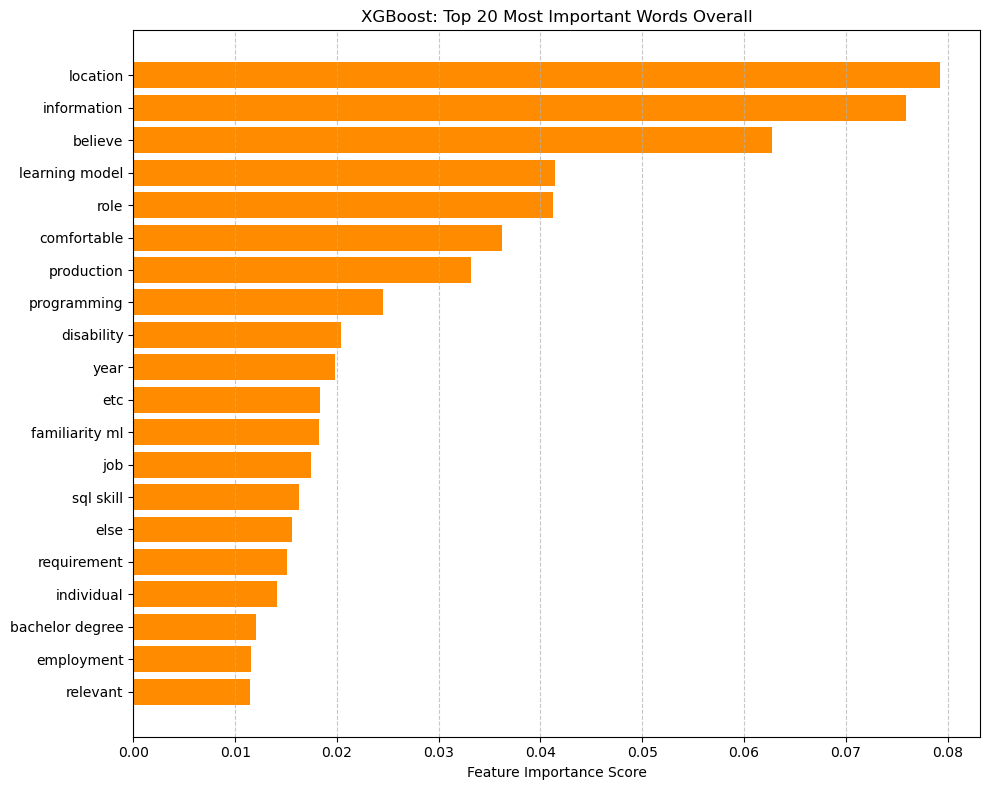

In [27]:
# Get feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# ==========================================
# 1. Logistic Regression (Directional)
# ==========================================
lr_coefficients = lr_model.coef_[0]

lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': lr_coefficients
}).sort_values(by='Weight', ascending=True)

lr_top_combined = pd.concat([lr_importance.head(15), lr_importance.tail(15)])

plt.figure(figsize=(10, 8))
colors = ['blue' if x < 0 else 'red' for x in lr_top_combined['Weight']]
plt.barh(lr_top_combined['Feature'], lr_top_combined['Weight'], color=colors)
plt.xlabel('Logistic Regression Weight')
plt.title('Logistic Regression: Top 15 Words Indicating Human (Blue) vs AI (Red)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# 2. Random Forest (Absolute Importance)
# ==========================================
rf_importances = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
})

# Get top 20 overall most important features, then sort ascending for plotting
rf_top_20 = rf_importance_df.sort_values(by='Importance', ascending=False).head(20)
rf_top_20 = rf_top_20.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(rf_top_20['Feature'], rf_top_20['Importance'], color='purple')
plt.xlabel('Gini Importance')
plt.title('Random Forest: Top 20 Most Important Words Overall')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# 3. XGBoost (Absolute Importance)
# ==========================================
xgb_importances = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
})

# Get top 20 overall most important features, then sort ascending for plotting
xgb_top_20 = xgb_importance_df.sort_values(by='Importance', ascending=False).head(20)
xgb_top_20 = xgb_top_20.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(xgb_top_20['Feature'], xgb_top_20['Importance'], color='darkorange')
plt.xlabel('Feature Importance Score')
plt.title('XGBoost: Top 20 Most Important Words Overall')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Extracting BERT embeddings...
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step 
Running t-SNE to compress embeddings to 2D...


/Users/andy/opt/anaconda3/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


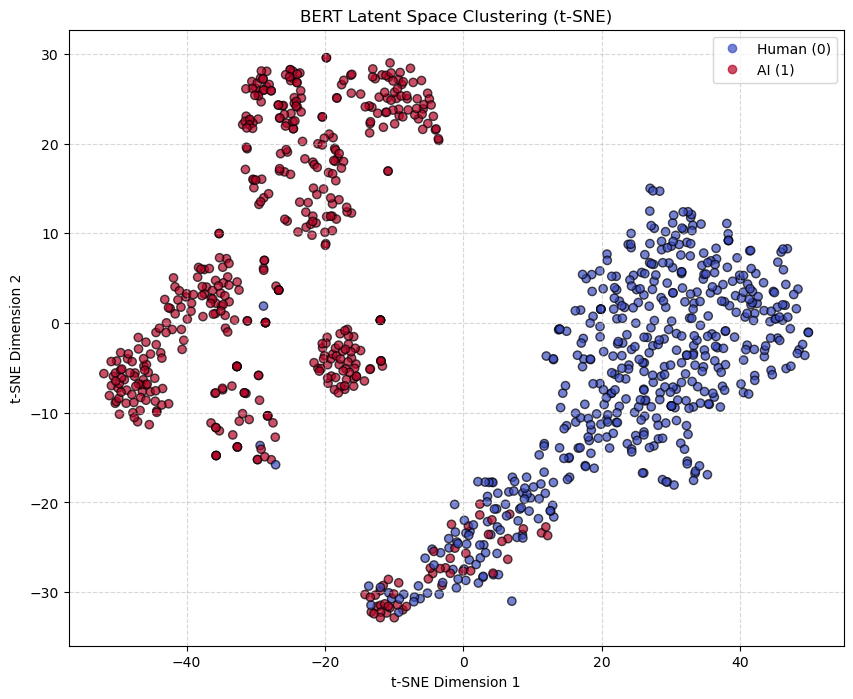

In [28]:
print("Extracting BERT embeddings...")
# Run the raw text through the preprocessor
processed_inputs = preprocessor(X_test_transformer)

# Pass the processed inputs through the BERT backbone to get embeddings
backbone_outputs = classifier.backbone.predict(processed_inputs)

# Extract the CLS token representation (pooled_output)
embeddings = backbone_outputs['pooled_output']

print("Running t-SNE to compress embeddings to 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plotting the Latent Space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y_test_np, 
                      cmap='coolwarm', edgecolors='k', alpha=0.7)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('BERT Latent Space Clustering (t-SNE)')

legend_elements = scatter.legend_elements()[0]
plt.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()